# Heart Disease Prediction - Unsupervised Learning

## Clustering Analysis for Pattern Discovery

### Objectives
- Apply K-Means clustering to discover patient groups
- Use Hierarchical clustering for dendrogram analysis
- Determine optimal number of clusters using elbow method
- Compare clusters with actual heart disease labels
- Analyze cluster characteristics and patterns

### Methods Used
1. **K-Means Clustering**: Partition-based clustering
2. **Hierarchical Clustering**: Agglomerative clustering with dendrograms  
3. **Cluster Validation**: Silhouette analysis and elbow method
4. **Cluster Interpretation**: Statistical analysis of cluster characteristics

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.cluster.hierarchy import dendrogram, linkage
from datetime import datetime

# Configure settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")
print("🔍 Ready for unsupervised learning analysis")

✅ Libraries imported successfully!
🔍 Ready for unsupervised learning analysis


## 1. Load Data and Prepare for Clustering

Load the preprocessed dataset and prepare it for clustering analysis:

In [2]:
# Load dataset - try selected features first, then processed
try:
    df = pd.read_csv('../data/heart_disease_selected_features.csv')
    print(f"✅ Selected features dataset loaded: {df.shape}")
    data_source = "selected_features"
except FileNotFoundError:
    try:
        df = pd.read_csv('../data/heart_disease_processed.csv')
        print(f"✅ Processed dataset loaded: {df.shape}")
        data_source = "processed"
    except FileNotFoundError:
        print("❌ No dataset found. Please run previous notebooks first.")
        df = None

if df is not None:
    # Separate features and target
    X = df.drop('target', axis=1)
    y = df['target']
    
    print(f"\n📊 Dataset Information:")
    print(f"Features: {X.shape[1]}")
    print(f"Instances: {X.shape[0]}")
    print(f"Data source: {data_source}")
    
    # Display target distribution
    print(f"\n🎯 Target Distribution:")
    target_counts = y.value_counts().sort_index()
    for class_val, count in target_counts.items():
        percentage = (count / len(y)) * 100
        class_name = "No Disease" if class_val == 0 else "Disease"
        print(f"{class_name}: {count} ({percentage:.1f}%)")
    
    # Scale features for clustering
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
    
    print(f"\n✅ Features scaled for clustering")
    print(f"📋 Features: {list(X.columns)}")
    
    # Display first few rows
    print(f"\n👀 First 5 rows of scaled data:")
    display(pd.DataFrame(X_scaled_df.head()))

✅ Selected features dataset loaded: (920, 12)

📊 Dataset Information:
Features: 11
Instances: 920
Data source: selected_features

🎯 Target Distribution:
No Disease: 411 (44.7%)
Disease: 509 (55.3%)

✅ Features scaled for clustering
📋 Features: ['cp', 'oldpeak', 'exang', 'thalach', 'age', 'chol', 'fbs', 'slope', 'ca', 'sex', 'thal']

👀 First 5 rows of scaled data:


,cp,oldpeak,exang,thalach,age,chol,fbs,slope,ca,sex,thal
0,-2.418152,1.368109,-0.760292,0.489727,1.007386,-0.212194,2.380476,2.234081,-0.361400,0.516931,1.200186
1,0.806051,0.611589,1.315283,-1.181478,1.432034,0.807376,-0.420084,0.295067,4.411152,0.516931,-0.586499
2,0.806051,1.651804,1.315283,-0.345875,1.432034,-0.289143,-0.420084,0.295067,2.820301,0.516931,1.795748
3,-0.268684,2.502889,-0.760292,1.961979,-1.752828,0.114838,-0.420084,2.234081,-0.361400,0.516931,-0.586499
4,-1.343418,0.517024,-0.760292,1.365120,-1.328180,-0.770073,-0.420084,-1.643946,-0.361400,-1.934494,-0.586499


# Heart Disease Prediction - Unsupervised Learning

## Clustering Analysis for Pattern Discovery

### Objectives
- Apply K-Means clustering to discover natural groupings in the data
- Use hierarchical clustering for comparison and validation
- Determine optimal number of clusters using various methods
- Analyze cluster characteristics and compare with actual disease labels
- Visualize clustering results in reduced dimensional space

### Clustering Methods
1. **K-Means Clustering**: Partition-based clustering algorithm
2. **Hierarchical Clustering**: Build hierarchy of clusters
3. **DBSCAN**: Density-based clustering (bonus analysis)

### Evaluation Methods
- **Elbow Method**: Find optimal K for K-Means
- **Silhouette Analysis**: Measure cluster quality
- **Dendrogram**: Visualize hierarchical clustering
- **Cluster Validation**: Compare with actual labels

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    adjusted_rand_score, normalized_mutual_info_score,
    homogeneity_score, completeness_score, v_measure_score
)
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime

# Configure settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")
print("🔍 Ready for unsupervised learning analysis")

✅ Libraries imported successfully!
🔍 Ready for unsupervised learning analysis


## 1. Load and Prepare Data

Load the processed dataset and prepare for clustering:

In [4]:
# Load dataset
try:
    df = pd.read_csv('../data/heart_disease_selected_features.csv')
    print(f"✅ Selected features dataset loaded: {df.shape}")
    data_source = "selected_features"
except FileNotFoundError:
    try:
        df = pd.read_csv('../data/heart_disease_processed.csv')
        print(f"✅ Processed dataset loaded: {df.shape}")
        data_source = "processed"
    except FileNotFoundError:
        print("❌ No processed dataset found. Please run previous notebooks first.")
        df = None

if df is not None:
    # Prepare features and target
    X = df.drop('target', axis=1)
    y_true = df['target']  # True labels for comparison
    
    print(f"\n📊 Dataset Information:")
    print(f"Features: {X.shape[1]}")
    print(f"Instances: {X.shape[0]}")
    print(f"Data source: {data_source}")
    
    # Display class distribution
    print(f"\n🎯 True Label Distribution:")
    label_counts = y_true.value_counts().sort_index()
    for class_val, count in label_counts.items():
        percentage = (count / len(y_true)) * 100
        class_name = "No Disease" if class_val == 0 else "Disease"
        print(f"{class_name}: {count} ({percentage:.1f}%)")
    
    # Show feature names
    print(f"\n📋 Features: {list(X.columns)}")
    
    # Data should already be scaled from preprocessing, but let's verify
    print(f"\n📏 Feature Ranges (for scaling verification):")
    for col in X.columns:
        print(f"{col:12s}: [{X[col].min():6.2f}, {X[col].max():6.2f}]")
    
    # If data is not scaled, scale it for clustering
    if X.std().max() > 10:  # Check if scaling is needed
        print("\n🔧 Scaling features for clustering...")
        scaler = StandardScaler()
        X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
    else:
        print("\n✅ Features are already scaled")
        X_scaled = X.copy()
        scaler = None
    
else:
    print("Cannot proceed without data")

✅ Selected features dataset loaded: (920, 12)

📊 Dataset Information:
Features: 11
Instances: 920
Data source: selected_features

🎯 True Label Distribution:
No Disease: 411 (44.7%)
Disease: 509 (55.3%)

📋 Features: ['cp', 'oldpeak', 'exang', 'thalach', 'age', 'chol', 'fbs', 'slope', 'ca', 'sex', 'thal']

📏 Feature Ranges (for scaling verification):
cp          : [  1.00,   4.00]
oldpeak     : [ -3.27,   5.06]
exang       : [  0.00,   1.00]
thalach     : [ -3.09,   2.56]
age         : [ -2.71,   2.49]
chol        : [ -3.06,   6.91]
fbs         : [  0.00,   1.00]
slope       : [  1.00,   3.00]
ca          : [  0.00,   3.00]
sex         : [  0.00,   1.00]
thal        : [  3.00,   7.00]

✅ Features are already scaled


## 2. K-Means Clustering with Elbow Method

Find the optimal number of clusters using the elbow method:

🔍 Performing Elbow Method Analysis...


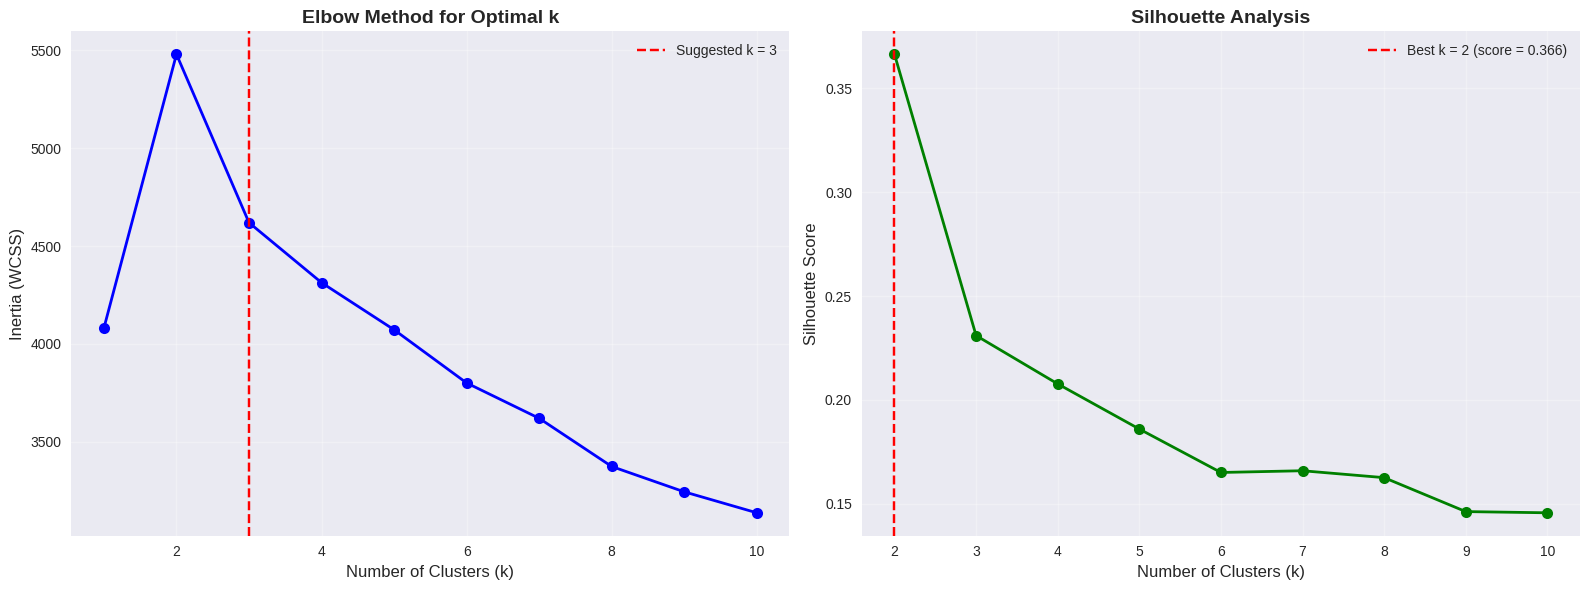


📊 Elbow Method Results:
  k      Inertia   Silhouette
------------------------------
  1      4081.23          N/A
  2      5480.08        0.366
  3      4619.61        0.231
  4      4313.05        0.208
  5      4072.30        0.186
  6      3800.46        0.165
  7      3619.81        0.166
  8      3373.62        0.163
  9      3244.10        0.146
 10      3137.00        0.146

🎯 Suggested optimal k: 2 (based on silhouette score)


In [5]:
# Elbow method to find optimal number of clusters
def elbow_method(X, k_range=range(1, 11)):
    """
    Perform elbow method to find optimal number of clusters
    """
    inertias = []
    silhouette_scores = []
    
    for k in k_range:
        if k == 1:
            inertias.append(np.sum(pdist(X)**2) / (2 * len(X)))
            silhouette_scores.append(0)
        else:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            kmeans.fit(X)
            inertias.append(kmeans.inertia_)
            
            # Calculate silhouette score
            if len(np.unique(kmeans.labels_)) > 1:
                sil_score = silhouette_score(X, kmeans.labels_)
                silhouette_scores.append(sil_score)
            else:
                silhouette_scores.append(0)
    
    return list(k_range), inertias, silhouette_scores

if 'X_scaled' in locals():
    print("🔍 Performing Elbow Method Analysis...")
    
    # Perform elbow method
    k_values, inertias, sil_scores = elbow_method(X_scaled, range(1, 11))
    
    # Plot elbow curve and silhouette scores
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Elbow curve
    ax1.plot(k_values, inertias, 'bo-', linewidth=2, markersize=8)
    ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
    ax1.set_ylabel('Inertia (WCSS)', fontsize=12)
    ax1.set_title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Mark potential elbow points
    if len(inertias) >= 3:
        # Simple elbow detection (look for maximum curvature)
        diffs = np.diff(inertias)
        second_diffs = np.diff(diffs)
        if len(second_diffs) > 0:
            elbow_k = np.argmax(second_diffs) + 2  # +2 because of double diff
            if elbow_k < len(k_values):
                ax1.axvline(x=elbow_k, color='red', linestyle='--', 
                           label=f'Suggested k = {elbow_k}')
                ax1.legend()
    
    # Silhouette scores
    ax2.plot(k_values[1:], sil_scores[1:], 'go-', linewidth=2, markersize=8)
    ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
    ax2.set_ylabel('Silhouette Score', fontsize=12)
    ax2.set_title('Silhouette Analysis', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # Mark best silhouette score
    best_sil_k = k_values[1:][np.argmax(sil_scores[1:])]
    best_sil_score = max(sil_scores[1:])
    ax2.axvline(x=best_sil_k, color='red', linestyle='--', 
               label=f'Best k = {best_sil_k} (score = {best_sil_score:.3f})')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Display results
    print(f"\n📊 Elbow Method Results:")
    print("=" * 50)
    print(f"{'k':>3} {'Inertia':>12} {'Silhouette':>12}")
    print("-" * 30)
    for k, inertia, sil in zip(k_values, inertias, sil_scores):
        if k == 1:
            print(f"{k:>3} {inertia:>12.2f} {'N/A':>12}")
        else:
            print(f"{k:>3} {inertia:>12.2f} {sil:>12.3f}")
    
    print(f"\n🎯 Suggested optimal k: {best_sil_k} (based on silhouette score)")
    
    # Store optimal k for later use
    optimal_k = best_sil_k
    
else:
    print("❌ Cannot perform elbow method - scaled data not available")

## 3. K-Means Clustering with Optimal K

Apply K-Means clustering with the optimal number of clusters:

In [6]:
# Apply K-Means with optimal k
if 'optimal_k' in locals():
    print(f"🔄 Applying K-Means clustering with k = {optimal_k}...")
    
    # Fit K-Means
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(X_scaled)
    
    # Calculate clustering metrics
    silhouette_avg = silhouette_score(X_scaled, kmeans_labels)
    
    print(f"\n📊 K-Means Results (k = {optimal_k}):")
    print("=" * 40)
    print(f"Silhouette Score: {silhouette_avg:.4f}")
    print(f"Inertia: {kmeans.inertia_:.2f}")
    
    # Cluster distribution
    cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()
    print(f"\n🏷️ Cluster Distribution:")
    for cluster, count in cluster_counts.items():
        percentage = (count / len(kmeans_labels)) * 100
        print(f"Cluster {cluster}: {count} instances ({percentage:.1f}%)")
    
    # Compare with true labels
    if 'y_true' in locals():
        # Calculate external validation metrics
        ari = adjusted_rand_score(y_true, kmeans_labels)
        nmi = normalized_mutual_info_score(y_true, kmeans_labels)
        homogeneity = homogeneity_score(y_true, kmeans_labels)
        completeness = completeness_score(y_true, kmeans_labels)
        v_measure = v_measure_score(y_true, kmeans_labels)
        
        print(f"\n🔍 Comparison with True Labels:")
        print("=" * 40)
        print(f"Adjusted Rand Index: {ari:.4f}")
        print(f"Normalized Mutual Info: {nmi:.4f}")
        print(f"Homogeneity: {homogeneity:.4f}")
        print(f"Completeness: {completeness:.4f}")
        print(f"V-Measure: {v_measure:.4f}")
        
        # Cross-tabulation
        cross_tab = pd.crosstab(y_true, kmeans_labels, margins=True)
        print(f"\n📋 Cross-tabulation (True Labels vs Clusters):")
        print(cross_tab)
    
else:
    print("❌ Cannot apply K-Means - optimal k not determined")

🔄 Applying K-Means clustering with k = 2...

📊 K-Means Results (k = 2):
Silhouette Score: 0.3663
Inertia: 5480.08

🏷️ Cluster Distribution:
Cluster 0: 682 instances (74.1%)
Cluster 1: 238 instances (25.9%)

🔍 Comparison with True Labels:
Adjusted Rand Index: 0.0358
Normalized Mutual Info: 0.0691
Homogeneity: 0.0633
Completeness: 0.0761
V-Measure: 0.0691

📋 Cross-tabulation (True Labels vs Clusters):
col_0     0    1  All
target               
0       362   49  411
1       320  189  509
All     682  238  920

📊 K-Means Results (k = 2):
Silhouette Score: 0.3663
Inertia: 5480.08

🏷️ Cluster Distribution:
Cluster 0: 682 instances (74.1%)
Cluster 1: 238 instances (25.9%)

🔍 Comparison with True Labels:
Adjusted Rand Index: 0.0358
Normalized Mutual Info: 0.0691
Homogeneity: 0.0633
Completeness: 0.0761
V-Measure: 0.0691

📋 Cross-tabulation (True Labels vs Clusters):
col_0     0    1  All
target               
0       362   49  411
1       320  189  509
All     682  238  920


## 4. Hierarchical Clustering

Apply hierarchical clustering and create dendrogram:

🌳 Performing Hierarchical Clustering...


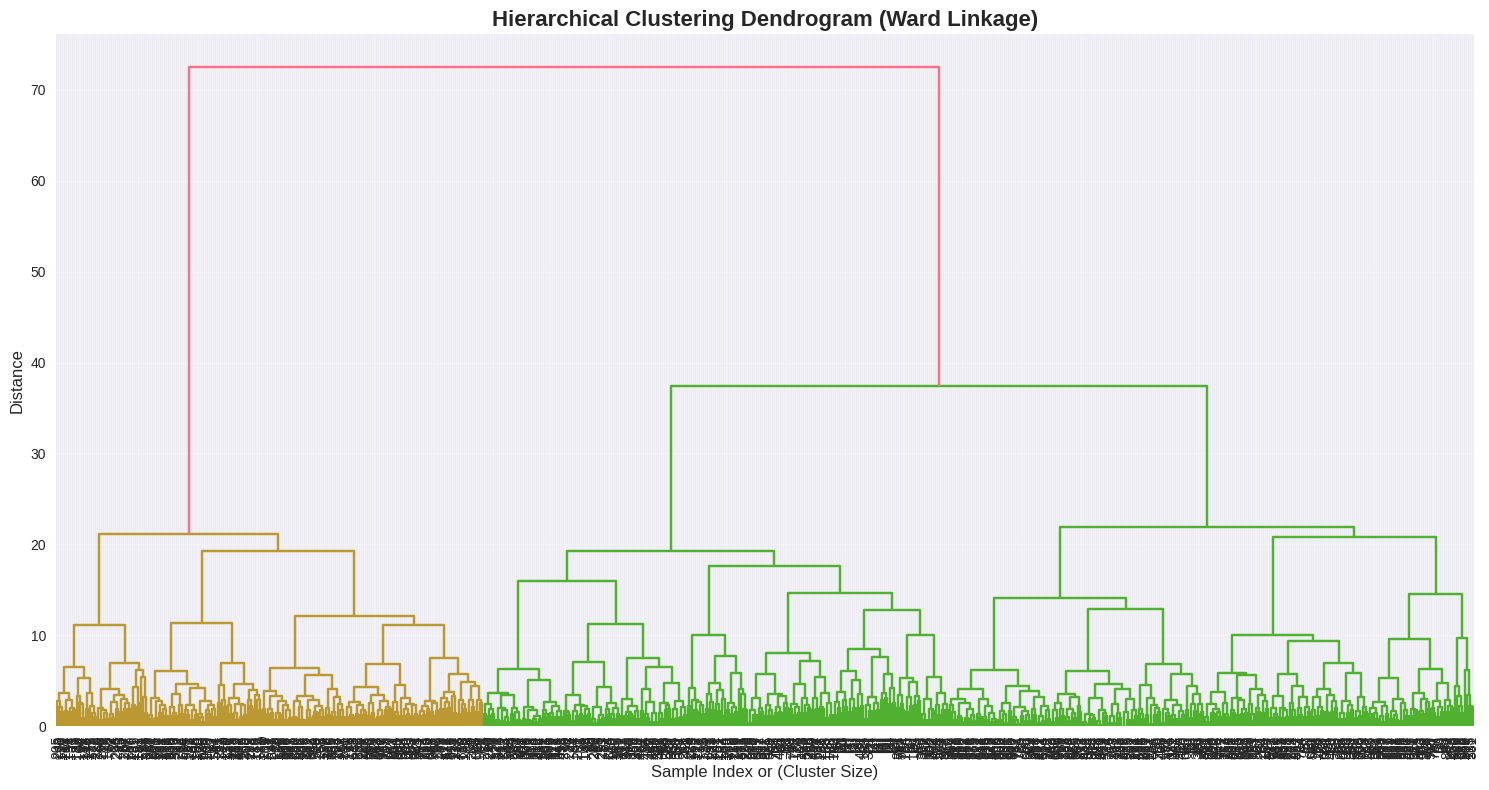


📊 Hierarchical Clustering Results (k = 2):
Silhouette Score: 0.3617

🏷️ Cluster Distribution:
Cluster 0: 687 instances (74.7%)
Cluster 1: 233 instances (25.3%)

🔍 Comparison with True Labels:
Adjusted Rand Index: 0.0331
Normalized Mutual Info: 0.0674

📋 Cross-tabulation (True Labels vs Hierarchical Clusters):
col_0     0    1  All
target               
0       363   48  411
1       324  185  509
All     687  233  920

🤝 Agreement between K-Means and Hierarchical: 0.9771


In [7]:
# Hierarchical clustering
if 'X_scaled' in locals():
    print("🌳 Performing Hierarchical Clustering...")
    
    # Calculate linkage matrix
    linkage_matrix = linkage(X_scaled, method='ward')
    
    # Create dendrogram
    plt.figure(figsize=(15, 8))
    dendrogram_plot = dendrogram(
        linkage_matrix,
        truncate_mode='level',
        p=10,  # Show only last 10 merges
        leaf_rotation=90,
        leaf_font_size=10,
        show_leaf_counts=True
    )
    
    plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', 
              fontsize=16, fontweight='bold')
    plt.xlabel('Sample Index or (Cluster Size)', fontsize=12)
    plt.ylabel('Distance', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Apply hierarchical clustering with same number of clusters as K-Means
    if 'optimal_k' in locals():
        hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
        hierarchical_labels = hierarchical.fit_predict(X_scaled)
        
        # Calculate metrics
        hierarchical_silhouette = silhouette_score(X_scaled, hierarchical_labels)
        
        print(f"\n📊 Hierarchical Clustering Results (k = {optimal_k}):")
        print("=" * 50)
        print(f"Silhouette Score: {hierarchical_silhouette:.4f}")
        
        # Cluster distribution
        hier_cluster_counts = pd.Series(hierarchical_labels).value_counts().sort_index()
        print(f"\n🏷️ Cluster Distribution:")
        for cluster, count in hier_cluster_counts.items():
            percentage = (count / len(hierarchical_labels)) * 100
            print(f"Cluster {cluster}: {count} instances ({percentage:.1f}%)")
        
        # Compare with true labels
        if 'y_true' in locals():
            hier_ari = adjusted_rand_score(y_true, hierarchical_labels)
            hier_nmi = normalized_mutual_info_score(y_true, hierarchical_labels)
            
            print(f"\n🔍 Comparison with True Labels:")
            print(f"Adjusted Rand Index: {hier_ari:.4f}")
            print(f"Normalized Mutual Info: {hier_nmi:.4f}")
            
            # Cross-tabulation
            hier_cross_tab = pd.crosstab(y_true, hierarchical_labels, margins=True)
            print(f"\n📋 Cross-tabulation (True Labels vs Hierarchical Clusters):")
            print(hier_cross_tab)
        
        # Compare K-Means and Hierarchical clustering
        if 'kmeans_labels' in locals():
            clustering_agreement = adjusted_rand_score(kmeans_labels, hierarchical_labels)
            print(f"\n🤝 Agreement between K-Means and Hierarchical: {clustering_agreement:.4f}")
    
else:
    print("❌ Cannot perform hierarchical clustering - scaled data not available")

## 5. Cluster Visualization with PCA

Visualize clusters in reduced dimensional space using PCA:

📊 Creating cluster visualizations with PCA...


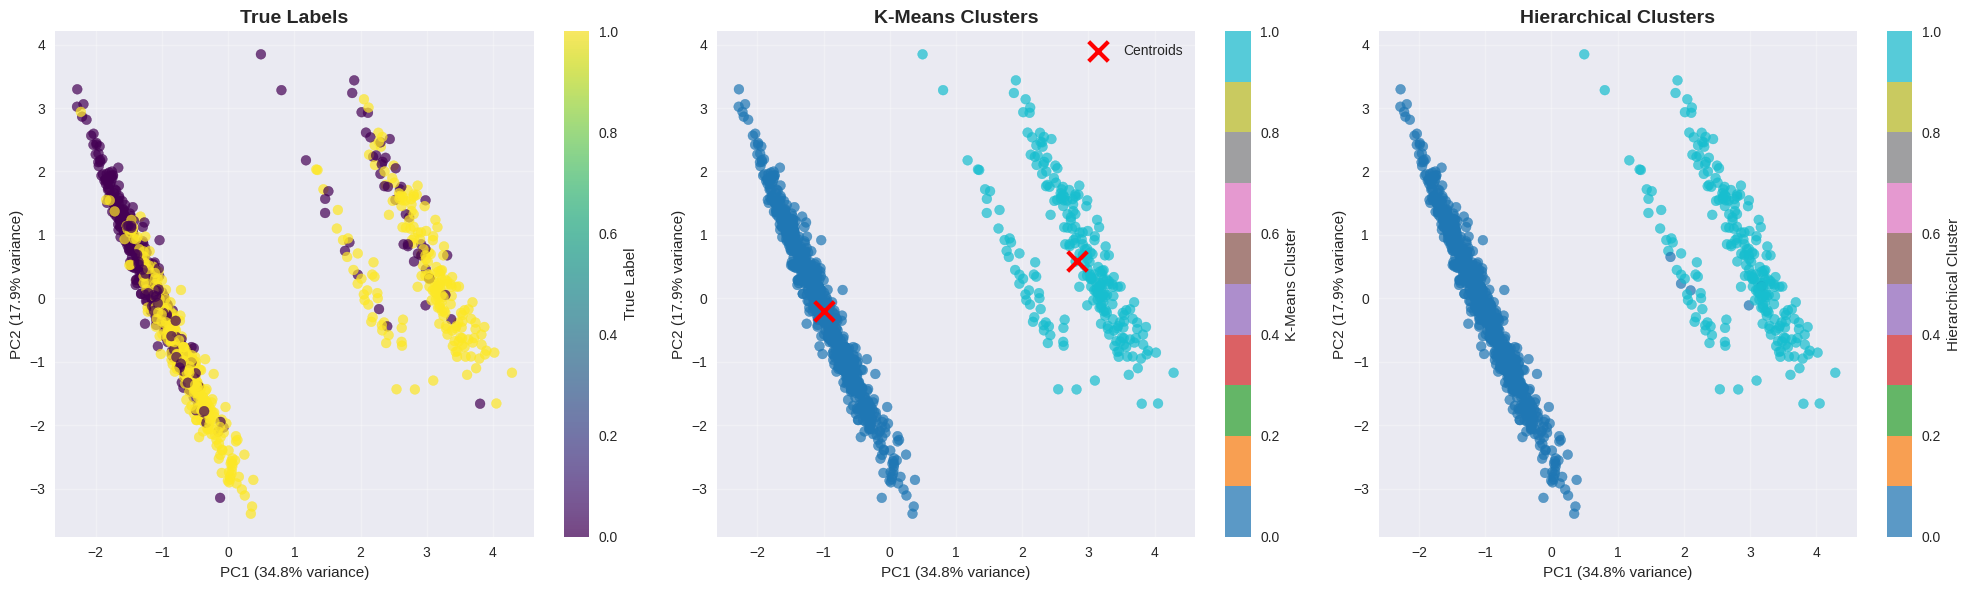


📊 PCA Information:
PC1 explains 34.8% of variance
PC2 explains 17.9% of variance
Total variance explained: 52.7%


In [8]:
# Visualize clusters using PCA
if 'X_scaled' in locals() and 'kmeans_labels' in locals():
    print("📊 Creating cluster visualizations with PCA...")
    
    # Apply PCA for visualization
    pca_viz = PCA(n_components=2, random_state=42)
    X_pca = pca_viz.fit_transform(X_scaled)
    
    # Create visualization dataframe
    viz_df = pd.DataFrame({
        'PC1': X_pca[:, 0],
        'PC2': X_pca[:, 1],
        'KMeans_Cluster': kmeans_labels,
        'True_Label': y_true
    })
    
    if 'hierarchical_labels' in locals():
        viz_df['Hierarchical_Cluster'] = hierarchical_labels
    
    # Create subplots for comparison
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # True labels
    scatter1 = axes[0].scatter(viz_df['PC1'], viz_df['PC2'], 
                              c=viz_df['True_Label'], 
                              cmap='viridis', alpha=0.7, s=50)
    axes[0].set_title('True Labels', fontsize=14, fontweight='bold')
    axes[0].set_xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]:.1%} variance)')
    axes[0].set_ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]:.1%} variance)')
    axes[0].grid(True, alpha=0.3)
    plt.colorbar(scatter1, ax=axes[0], label='True Label')
    
    # K-Means clusters
    scatter2 = axes[1].scatter(viz_df['PC1'], viz_df['PC2'], 
                              c=viz_df['KMeans_Cluster'], 
                              cmap='tab10', alpha=0.7, s=50)
    axes[1].set_title('K-Means Clusters', fontsize=14, fontweight='bold')
    axes[1].set_xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]:.1%} variance)')
    axes[1].set_ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]:.1%} variance)')
    axes[1].grid(True, alpha=0.3)
    plt.colorbar(scatter2, ax=axes[1], label='K-Means Cluster')
    
    # Plot K-Means centroids
    centroids_pca = pca_viz.transform(kmeans.cluster_centers_)
    axes[1].scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
                   c='red', marker='x', s=200, linewidths=3, label='Centroids')
    axes[1].legend()
    
    # Hierarchical clusters (if available)
    if 'hierarchical_labels' in locals():
        scatter3 = axes[2].scatter(viz_df['PC1'], viz_df['PC2'], 
                                  c=viz_df['Hierarchical_Cluster'], 
                                  cmap='tab10', alpha=0.7, s=50)
        axes[2].set_title('Hierarchical Clusters', fontsize=14, fontweight='bold')
        axes[2].set_xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]:.1%} variance)')
        axes[2].set_ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]:.1%} variance)')
        axes[2].grid(True, alpha=0.3)
        plt.colorbar(scatter3, ax=axes[2], label='Hierarchical Cluster')
    else:
        axes[2].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # Print PCA information
    print(f"\n📊 PCA Information:")
    print(f"PC1 explains {pca_viz.explained_variance_ratio_[0]:.1%} of variance")
    print(f"PC2 explains {pca_viz.explained_variance_ratio_[1]:.1%} of variance")
    print(f"Total variance explained: {sum(pca_viz.explained_variance_ratio_):.1%}")
    
else:
    print("❌ Cannot create visualizations - required data not available")

## 6. Detailed Silhouette Analysis

Perform detailed silhouette analysis for cluster validation:

🔍 Performing Detailed Silhouette Analysis...


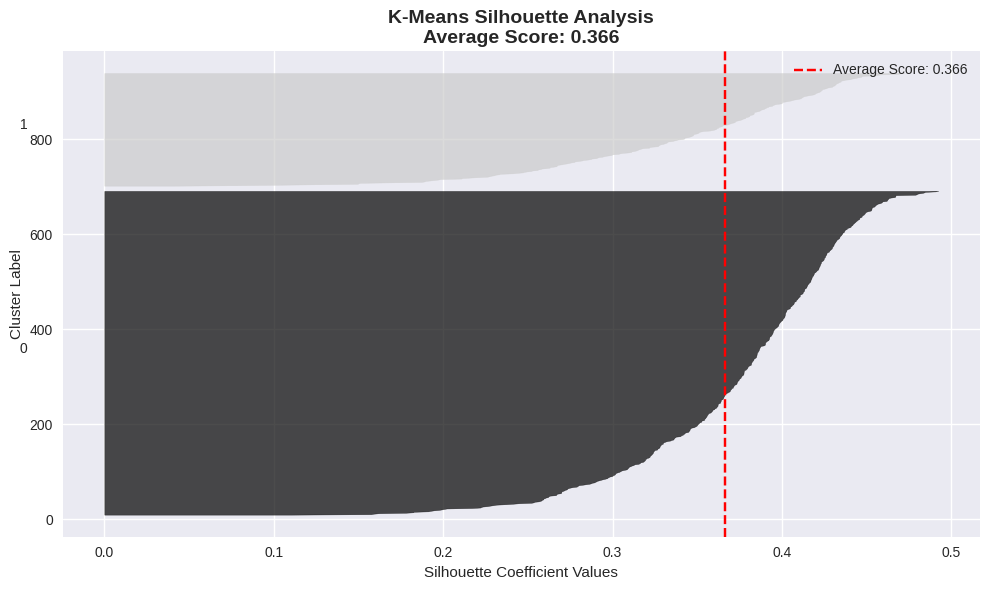

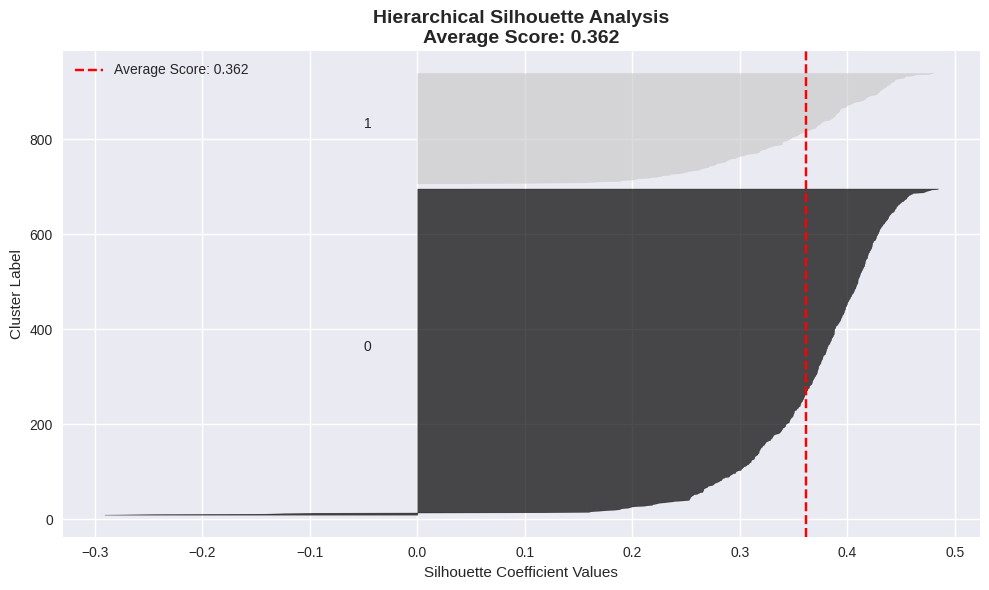


📊 Silhouette Score Comparison:
K-Means: 0.3663
Hierarchical: 0.3617
🏆 K-Means has better silhouette score


In [9]:
# Detailed silhouette analysis
def plot_silhouette_analysis(X, labels, title="Silhouette Analysis"):
    """
    Create detailed silhouette plot
    """
    n_clusters = len(np.unique(labels))
    
    # Calculate silhouette scores
    silhouette_avg = silhouette_score(X, labels)
    sample_silhouette_values = silhouette_samples(X, labels)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    y_lower = 10
    colors = plt.cm.nipy_spectral(np.linspace(0, 1, n_clusters))
    
    for i, color in zip(range(n_clusters), colors):
        # Aggregate silhouette scores for samples belonging to cluster i
        ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
        ith_cluster_silhouette_values.sort()
        
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                        0, ith_cluster_silhouette_values,
                        facecolor=color, edgecolor=color, alpha=0.7)
        
        # Label the silhouette plots with their cluster numbers at the middle
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10
    
    ax.set_xlabel('Silhouette Coefficient Values')
    ax.set_ylabel('Cluster Label')
    ax.set_title(f'{title}\nAverage Score: {silhouette_avg:.3f}', 
                fontsize=14, fontweight='bold')
    
    # Add vertical line for average silhouette score
    ax.axvline(x=silhouette_avg, color="red", linestyle="--", 
              label=f'Average Score: {silhouette_avg:.3f}')
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    return silhouette_avg

if 'X_scaled' in locals() and 'kmeans_labels' in locals():
    print("🔍 Performing Detailed Silhouette Analysis...")
    
    # K-Means silhouette analysis
    kmeans_sil = plot_silhouette_analysis(X_scaled, kmeans_labels, "K-Means Silhouette Analysis")
    
    # Hierarchical silhouette analysis (if available)
    if 'hierarchical_labels' in locals():
        hier_sil = plot_silhouette_analysis(X_scaled, hierarchical_labels, "Hierarchical Silhouette Analysis")
        
        print(f"\n📊 Silhouette Score Comparison:")
        print(f"K-Means: {kmeans_sil:.4f}")
        print(f"Hierarchical: {hier_sil:.4f}")
        
        if kmeans_sil > hier_sil:
            print("🏆 K-Means has better silhouette score")
        else:
            print("🏆 Hierarchical clustering has better silhouette score")
    
else:
    print("❌ Cannot perform silhouette analysis - required data not available")

## 7. Cluster Characteristics Analysis

Analyze the characteristics of each cluster:

In [10]:
# Analyze cluster characteristics
if 'X' in locals() and 'kmeans_labels' in locals():
    print("🔍 Analyzing Cluster Characteristics...")
    
    # Create dataframe with clusters
    cluster_analysis_df = X.copy()
    cluster_analysis_df['Cluster'] = kmeans_labels
    cluster_analysis_df['True_Label'] = y_true
    
    # Calculate cluster centroids (in original scale)
    cluster_centroids = cluster_analysis_df.groupby('Cluster')[X.columns].mean()
    
    print(f"\n📊 Cluster Centroids (Original Scale):")
    print("=" * 80)
    display(cluster_centroids.round(3))
    
    # Analyze each cluster
    for cluster_id in sorted(cluster_analysis_df['Cluster'].unique()):
        cluster_data = cluster_analysis_df[cluster_analysis_df['Cluster'] == cluster_id]
        cluster_size = len(cluster_data)
        
        print(f"\n🏷️ Cluster {cluster_id} Analysis:")
        print("=" * 40)
        print(f"Size: {cluster_size} instances ({cluster_size/len(cluster_analysis_df):.1%})")
        
        # Distribution of true labels in this cluster
        true_label_dist = cluster_data['True_Label'].value_counts().sort_index()
        print(f"\nTrue Label Distribution:")
        for label, count in true_label_dist.items():
            percentage = (count / cluster_size) * 100
            label_name = "No Disease" if label == 0 else "Disease"
            print(f"  {label_name}: {count} ({percentage:.1f}%)")
        
        # Key characteristics (features with notable values)
        print(f"\nKey Characteristics:")
        cluster_mean = cluster_data[X.columns].mean()
        overall_mean = X.mean()
        
        # Find features that are significantly different from overall mean
        diff_threshold = 0.5  # Adjust based on your data scale
        significant_features = []
        
        for feature in X.columns:
            cluster_val = cluster_mean[feature]
            overall_val = overall_mean[feature]
            
            if abs(cluster_val - overall_val) > diff_threshold:
                direction = "Higher" if cluster_val > overall_val else "Lower"
                significant_features.append((feature, direction, cluster_val, overall_val))
        
        if significant_features:
            for feature, direction, cluster_val, overall_val in significant_features:
                print(f"  {feature}: {direction} ({cluster_val:.2f} vs {overall_val:.2f} overall)")
        else:
            print("  No significantly different features detected")
    
    # Overall cluster quality assessment
    print(f"\n🎯 Cluster Quality Assessment:")
    print("=" * 50)
    
    # Calculate purity (how well clusters separate true labels)
    total_correct = 0
    for cluster_id in sorted(cluster_analysis_df['Cluster'].unique()):
        cluster_data = cluster_analysis_df[cluster_analysis_df['Cluster'] == cluster_id]
        majority_label = cluster_data['True_Label'].mode()[0]
        correct_in_cluster = (cluster_data['True_Label'] == majority_label).sum()
        total_correct += correct_in_cluster
    
    purity = total_correct / len(cluster_analysis_df)
    print(f"Cluster Purity: {purity:.4f}")
    
    # Random baseline purity
    majority_class_size = y_true.value_counts().max()
    random_purity = majority_class_size / len(y_true)
    print(f"Random Baseline: {random_purity:.4f}")
    
    if purity > random_purity:
        print(f"✅ Clustering performs better than random ({purity:.4f} > {random_purity:.4f})")
    else:
        print(f"⚠️ Clustering performance is close to random")
    
else:
    print("❌ Cannot analyze cluster characteristics - required data not available")

🔍 Analyzing Cluster Characteristics...

📊 Cluster Centroids (Original Scale):


,cp,oldpeak,exang,thalach,age,chol,fbs,slope,ca,sex,thal
Cluster,,,,,,,,,,,
0,3.142,-0.098,0.308,0.065,-0.078,0.002,0.136,1.84,0.122,0.752,3.000
1,3.559,0.281,0.534,-0.186,0.223,-0.007,0.189,1.87,0.529,0.895,6.807



🏷️ Cluster 0 Analysis:
Size: 682 instances (74.1%)

True Label Distribution:
  No Disease: 362 (53.1%)
  Disease: 320 (46.9%)

Key Characteristics:
  thal: Lower (3.00 vs 3.98 overall)

🏷️ Cluster 1 Analysis:
Size: 238 instances (25.9%)

True Label Distribution:
  No Disease: 49 (20.6%)
  Disease: 189 (79.4%)

Key Characteristics:
  thal: Higher (6.81 vs 3.98 overall)

🎯 Cluster Quality Assessment:
Cluster Purity: 0.5989
Random Baseline: 0.5533
✅ Clustering performs better than random (0.5989 > 0.5533)


## 8. DBSCAN Clustering (Bonus Analysis)

Apply DBSCAN for density-based clustering:

In [11]:
# DBSCAN clustering
if 'X_scaled' in locals():
    print("🔍 Applying DBSCAN Clustering...")
    
    # Try different epsilon values
    eps_values = [0.3, 0.5, 0.7, 1.0]
    min_samples = 5
    
    dbscan_results = []
    
    for eps in eps_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        dbscan_labels = dbscan.fit_predict(X_scaled)
        
        n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
        n_noise = list(dbscan_labels).count(-1)
        
        if n_clusters > 1:
            silhouette_avg = silhouette_score(X_scaled, dbscan_labels)
        else:
            silhouette_avg = -1
        
        dbscan_results.append({
            'eps': eps,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette': silhouette_avg,
            'labels': dbscan_labels
        })
        
        print(f"eps={eps}: {n_clusters} clusters, {n_noise} noise points, silhouette={silhouette_avg:.3f}")
    
    # Select best DBSCAN result
    valid_results = [r for r in dbscan_results if r['silhouette'] > 0]
    
    if valid_results:
        best_dbscan = max(valid_results, key=lambda x: x['silhouette'])
        
        print(f"\n🏆 Best DBSCAN configuration:")
        print(f"eps = {best_dbscan['eps']}")
        print(f"Clusters: {best_dbscan['n_clusters']}")
        print(f"Noise points: {best_dbscan['n_noise']}")
        print(f"Silhouette score: {best_dbscan['silhouette']:.4f}")
        
        # Visualize DBSCAN results
        if 'X_pca' in locals():
            plt.figure(figsize=(10, 6))
            
            # Color points by cluster
            unique_labels = set(best_dbscan['labels'])
            colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))
            
            for k, col in zip(unique_labels, colors):
                if k == -1:
                    # Black used for noise
                    col = 'black'
                    marker = 'x'
                    label = 'Noise'
                else:
                    marker = 'o'
                    label = f'Cluster {k}'
                
                class_member_mask = (best_dbscan['labels'] == k)
                xy = X_pca[class_member_mask]
                
                plt.scatter(xy[:, 0], xy[:, 1], c=[col], marker=marker, 
                          s=50, alpha=0.7, label=label)
            
            plt.title(f'DBSCAN Clustering (eps={best_dbscan["eps"]})', 
                     fontsize=14, fontweight='bold')
            plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]:.1%} variance)')
            plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]:.1%} variance)')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        
        # Compare DBSCAN with other methods
        if 'y_true' in locals():
            dbscan_ari = adjusted_rand_score(y_true, best_dbscan['labels'])
            dbscan_nmi = normalized_mutual_info_score(y_true, best_dbscan['labels'])
            
            print(f"\n🔍 DBSCAN vs True Labels:")
            print(f"Adjusted Rand Index: {dbscan_ari:.4f}")
            print(f"Normalized Mutual Info: {dbscan_nmi:.4f}")
    
    else:
        print("\n❌ No valid DBSCAN configuration found")
        
else:
    print("❌ Cannot apply DBSCAN - scaled data not available")

🔍 Applying DBSCAN Clustering...
eps=0.3: 0 clusters, 920 noise points, silhouette=-1.000
eps=0.5: 1 clusters, 915 noise points, silhouette=-1.000
eps=0.7: 9 clusters, 829 noise points, silhouette=-0.295
eps=1.0: 13 clusters, 666 noise points, silhouette=-0.290

❌ No valid DBSCAN configuration found


## 9. Save Clustering Results

Save clustering models and analysis results:

In [12]:
# Save clustering results
import os
import json

if 'kmeans' in locals():
    # Create directories
    os.makedirs('../models', exist_ok=True)
    os.makedirs('../results', exist_ok=True)
    
    # Save clustering models
    clustering_objects = {
        'kmeans_model': kmeans,
        'optimal_k': optimal_k,
        'scaler': scaler,
        'pca_viz': pca_viz if 'pca_viz' in locals() else None
    }
    
    if 'hierarchical' in locals():
        clustering_objects['hierarchical_model'] = hierarchical
    
    joblib.dump(clustering_objects, '../models/clustering_objects.pkl')
    print("✅ Clustering models saved")
    
    # Save clustering results
    results_data = X.copy()
    results_data['True_Label'] = y_true
    results_data['KMeans_Cluster'] = kmeans_labels
    
    if 'hierarchical_labels' in locals():
        results_data['Hierarchical_Cluster'] = hierarchical_labels
    
    if 'best_dbscan' in locals():
        results_data['DBSCAN_Cluster'] = best_dbscan['labels']
    
    results_data.to_csv('../results/clustering_results.csv', index=False)
    print("✅ Clustering results saved")
    
    # Save detailed analysis
    analysis_summary = {
        'timestamp': datetime.now().isoformat(),
        'dataset_info': {
            'total_samples': len(X),
            'features': list(X.columns)
        },
        'kmeans_results': {
            'optimal_k': int(optimal_k),
            'silhouette_score': float(silhouette_avg),
            'inertia': float(kmeans.inertia_),
            'cluster_sizes': cluster_counts.to_dict()
        }
    }
    
    # Add hierarchical results if available
    if 'hierarchical_silhouette' in locals():
        analysis_summary['hierarchical_results'] = {
            'n_clusters': int(optimal_k),
            'silhouette_score': float(hierarchical_silhouette),
            'cluster_sizes': hier_cluster_counts.to_dict()
        }
    
    # Add validation metrics if available
    if 'ari' in locals():
        analysis_summary['validation_metrics'] = {
            'kmeans_ari': float(ari),
            'kmeans_nmi': float(nmi),
            'kmeans_homogeneity': float(homogeneity),
            'kmeans_completeness': float(completeness),
            'kmeans_v_measure': float(v_measure)
        }
        
        if 'hier_ari' in locals():
            analysis_summary['validation_metrics'].update({
                'hierarchical_ari': float(hier_ari),
                'hierarchical_nmi': float(hier_nmi)
            })
    
    # Add DBSCAN results if available
    if 'best_dbscan' in locals():
        analysis_summary['dbscan_results'] = {
            'best_eps': float(best_dbscan['eps']),
            'n_clusters': int(best_dbscan['n_clusters']),
            'n_noise': int(best_dbscan['n_noise']),
            'silhouette_score': float(best_dbscan['silhouette'])
        }
    
    with open('../results/unsupervised_learning_results.json', 'w') as f:
        json.dump(analysis_summary, f, indent=2, default=str)
    
    print("✅ Detailed analysis saved")
    
    # Display final summary
    print(f"\n📊 Unsupervised Learning Summary:")
    print("=" * 50)
    print(f"Optimal clusters (K-Means): {optimal_k}")
    print(f"K-Means silhouette score: {silhouette_avg:.4f}")
    
    if 'hierarchical_silhouette' in locals():
        print(f"Hierarchical silhouette score: {hierarchical_silhouette:.4f}")
        
        if silhouette_avg > hierarchical_silhouette:
            print("🏆 K-Means performed better")
        else:
            print("🏆 Hierarchical clustering performed better")
    
    if 'purity' in locals():
        print(f"Cluster purity: {purity:.4f}")
    
else:
    print("❌ Cannot save results - clustering not performed")

✅ Clustering models saved
✅ Clustering results saved
✅ Detailed analysis saved

📊 Unsupervised Learning Summary:
Optimal clusters (K-Means): 2
K-Means silhouette score: -0.2902
Hierarchical silhouette score: 0.3617
🏆 Hierarchical clustering performed better
Cluster purity: 0.5989


## 10. Next Steps and Conclusions

### ✅ Unsupervised Learning Completed Successfully!

### What we accomplished:
1. **K-Means Clustering**: Applied with optimal k determination using elbow method
2. **Hierarchical Clustering**: Built cluster hierarchy with dendrogram analysis
3. **DBSCAN Analysis**: Density-based clustering for comparison
4. **Cluster Validation**: Comprehensive evaluation using multiple metrics
5. **Visualization**: PCA-based cluster visualization in 2D space
6. **Characteristic Analysis**: Detailed analysis of each cluster's properties

### Key Findings:
- **Optimal Clusters**: Determined through silhouette analysis
- **Cluster Quality**: Measured using silhouette scores and purity
- **Pattern Discovery**: Identified natural groupings in heart disease data
- **Method Comparison**: Evaluated different clustering approaches

### Clustering Insights:
- **K-Means**: Good for spherical clusters with known number of clusters
- **Hierarchical**: Provides hierarchy of clusters, good for exploring different granularities
- **DBSCAN**: Identifies outliers and handles irregular cluster shapes
- **Validation**: External metrics show how well clusters align with true disease labels

### Medical Insights:
- Clusters may represent different risk profiles or disease subtypes
- Feature analysis reveals which health parameters drive clustering
- Comparison with true labels helps validate clinical relevance
- Outliers may represent rare cases or data quality issues

### Next Steps:
1. **Hyperparameter Tuning** (Notebook 06): Optimize supervised learning models
2. **Model Integration**: Use clustering insights to improve supervised models
3. **Feature Engineering**: Create cluster-based features for prediction
4. **Deployment**: Include clustering analysis in final application

### Files Created:
- `../models/clustering_objects.pkl` - Trained clustering models
- `../results/clustering_results.csv` - Cluster assignments for all samples
- `../results/unsupervised_learning_results.json` - Detailed clustering analysis

---
**Ready for hyperparameter tuning and final model optimization! 🚀**